Final CG Offset from Origin (X coordinate): -0.00 mm
Final CG Offset from Origin (Y coordinate): -0.00 mm


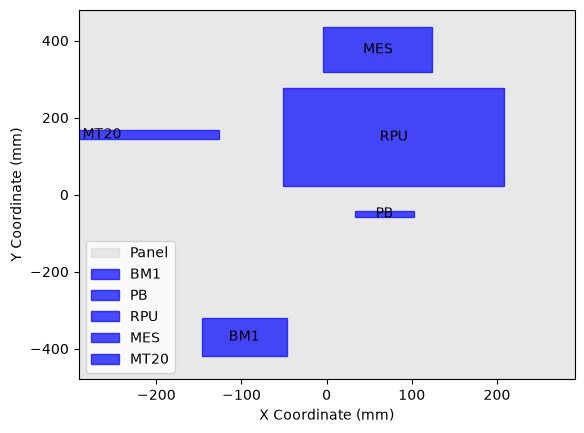

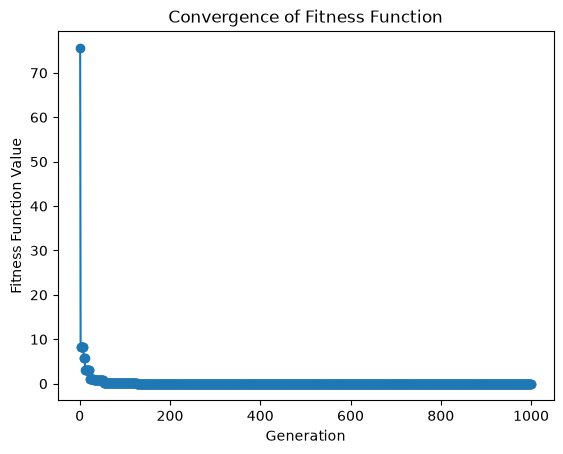

In [1]:
# JSON
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# Define the fitness function (minimize the CG offset from the origin)
def evaluate(individual, element_data):
    masses = element_data[:, 0].astype(float) # Convert mass values to floats
    total_mass = np.sum(masses) # Use np.sum() for scalar sum

    # Calculate the centroid coordinates using vectorized operations
    cg_x = np.dot(individual[::2], masses) / total_mass # Ensure scalar division
    cg_y = np.dot(individual[1::2], masses) / total_mass # Ensure scalar division

    # Calculate CG offset as the primary objective
    cog_penalty = cg_x**2 + cg_y**2

    # Check for overlaps and add penalty using vectorized operations
    num_elements = len(element_data)
    overlap_penalty = 0.0
    for i in range(num_elements):
        x1, y1 = individual[i * 2], individual[i * 2 + 1]
        length1, width1 = element_data[i][1], element_data[i][2]
        for j in range(i + 1, num_elements):
            x2, y2 = individual[j * 2], individual[j * 2 + 1]
            length2, width2 = element_data[j][1], element_data[j][2]
            
            # Calculate overlap
            overlap_x = max(0, min(x1 + length1/2, x2 + length2/2) - max(x1 - length1/2, x2 - length2/2))
            overlap_y = max(0, min(y1 + width1/2, y2 + width2/2) - max(y1 - width1/2, y2 - width2/2))
            if overlap_x > 0 and overlap_y > 0:
                overlap_penalty += (overlap_x * overlap_y) * 10000

    # Add penalty to the fitness value
    return cog_penalty + overlap_penalty

# Load data from JSON file
try:
    with open(r"/Users/neerajprao/Desktop/isro/prev_work/objects.json", "r") as json_file:
        data = json.load(json_file)
except FileNotFoundError:
    print("The file was not found.")
    exit()

board_data = data.get('BOARD', {})
components_data = data.get('COMPONENTS', [])

# Extract panel dimensions and number of elements
panel_width = board_data.get('Breadth (mm)', 0)
panel_height = board_data.get('Length (mm)', 0)
num_elements = len(components_data)

if num_elements == 0:
    print("No components found in the JSON data.")
    exit()

# Initialize lists to store element data
element_data = []
element_names = []
for component in components_data:
    try:
        element_name = component['Object name']
        length = float(component.get('Length (mm)', 0))
        width = float(component.get('Breadth (mm)', 0))
        mass = float(component.get('Weight (kg)', 0))
        element_data.append([mass, length, width])
        element_names.append(element_name)
    except KeyError as e:
        print(f"Missing key in component data: {e}")
        exit()

# Convert element_data to a NumPy array
element_data = np.array(element_data, dtype=float)
if len(element_data) == 0:
    print("No valid element data found.")
    exit()

# Define bounds for DE optimization
bounds = [(-panel_width/2, panel_width/2), (-panel_height/2, panel_height/2)] * num_elements

# Create a callback function to track convergence
convergence_data = []
def callback(xk, convergence=None):
    convergence_data.append(evaluate(xk, element_data))

# Perform Differential Evolution optimization
try:
    result = differential_evolution(
        evaluate, bounds, args=(element_data,),
        maxiter=1000, popsize=100, tol=1e-6, strategy='best1bin',
        callback=callback
    )
except Exception as e:
    print(f"Optimization error: {e}")
    exit()

# Extract the best individual and its fitness value
best_individual = result.x
best_fitness_value = result.fun

# Calculate and display the minimized CG offset
total_mass = np.sum(element_data[:, 0])
final_cg_x = np.dot(best_individual[::2], element_data[:, 0]) / total_mass
final_cg_y = np.dot(best_individual[1::2], element_data[:, 0]) / total_mass

print(f"Final CG Offset from Origin (X coordinate): {final_cg_x:.2f} mm")
print(f"Final CG Offset from Origin (Y coordinate): {final_cg_y:.2f} mm")

# Create a figure and axis for plotting
fig, ax = plt.subplots()

# Plot the panel as a rectangle
panel_rect = plt.Rectangle(
    (-panel_width/2, -panel_height/2),
    panel_width, panel_height, color='lightgray',
    alpha=0.5, label='Panel'
)
ax.add_patch(panel_rect)

# Plot the elements on the panel and display element names
for i in range(num_elements):
    x, y = best_individual[i * 2], best_individual[i * 2 + 1]
    length, width = element_data[i][1], element_data[i][2]
    element_rect = plt.Rectangle(
        (x - length/2, y - width/2),
        length, width, color='blue', alpha=0.7,
        label=element_names[i]
    )
    ax.add_patch(element_rect)
    ax.text(x, y, element_names[i], color='black', ha='center', va='center')

# Set axis limits and labels
ax.set_xlim(-panel_width/2, panel_width/2)
ax.set_ylim(-panel_height/2, panel_height/2)
ax.set_xlabel("X Coordinate (mm)")
ax.set_ylabel("Y Coordinate (mm)")
ax.legend()
plt.show()

# Plot the convergence of the fitness function
plt.figure()
plt.plot(range(1, len(convergence_data) + 1), convergence_data, marker='o', linestyle='-')
plt.xlabel("Generation")
plt.ylabel("Fitness Function Value")
plt.title("Convergence of Fitness Function")
plt.show()

Searching for 5 unique non-overlapping configurations...
Identified valid unique configuration 1/5
Identified valid unique configuration 2/5
Identified valid unique configuration 3/5
Identified valid unique configuration 4/5
Identified valid unique configuration 5/5

Successfully identified 5 unique configurations.

Configuration 1:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  402.7019        -88.8962       
PB                   4.7778          -231.8520      
RPU                  -188.7560       28.3859        
MES                  129.4336        -211.2755      
MT20                 -136.1043       244.4528       


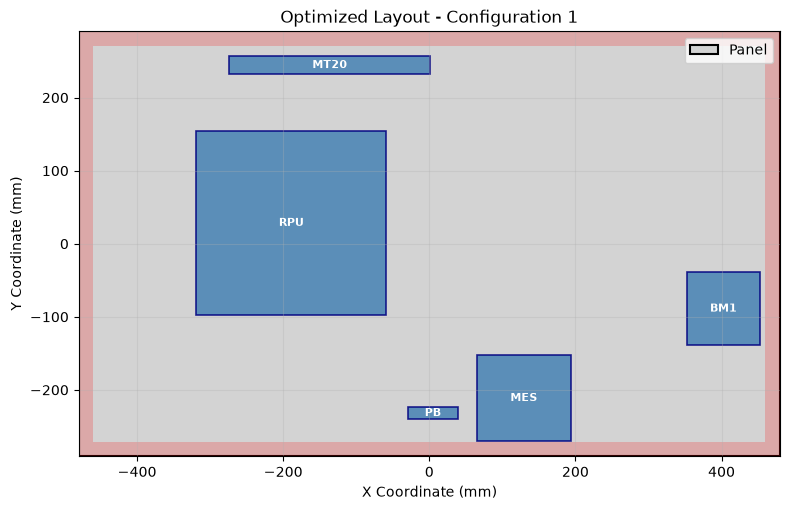

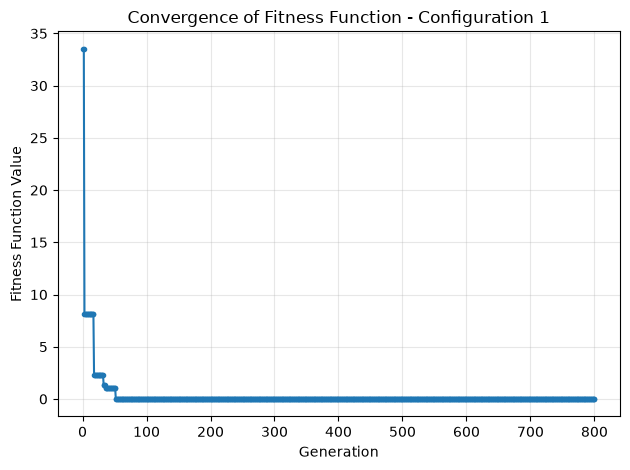

Configuration 2:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  -164.2685       36.1812        
PB                   -255.2383       25.9508        
RPU                  133.2462        17.4295        
MES                  -83.5670        -157.6101      
MT20                 -293.4154       -223.6354      


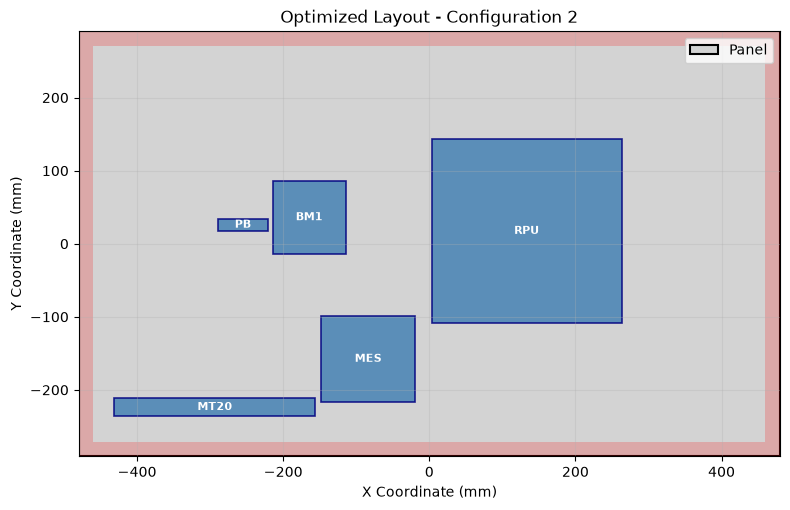

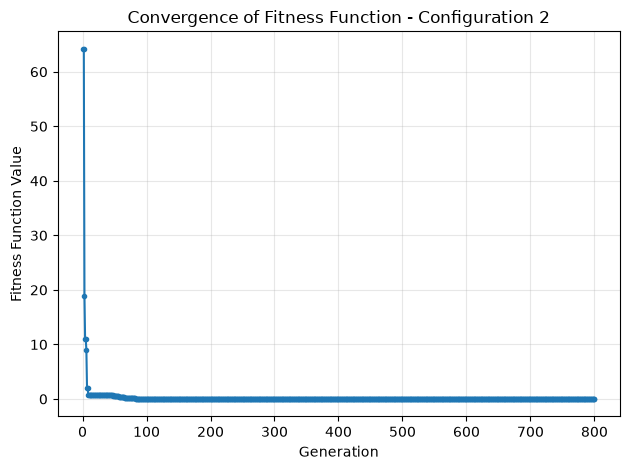

Configuration 3:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  218.3341        200.3787       
PB                   116.5017        -31.0155       
RPU                  -161.8354       -75.6725       
MES                  320.1383        -203.9396      
MT20                 265.8436        -112.3912      


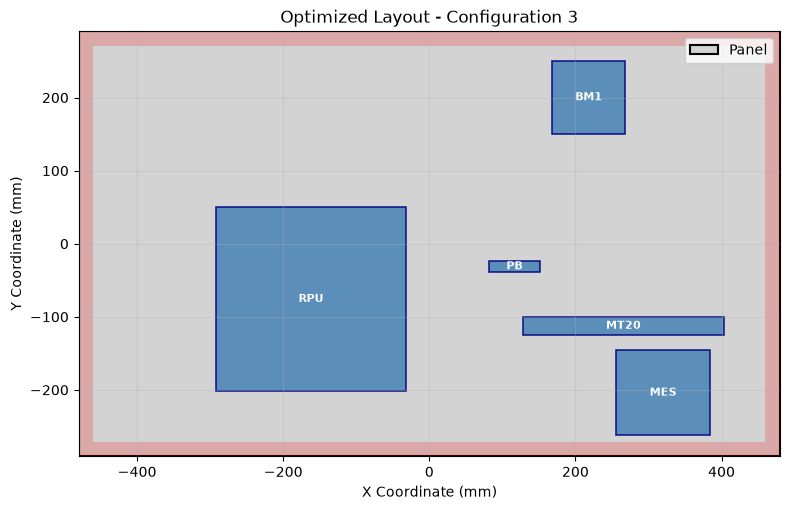

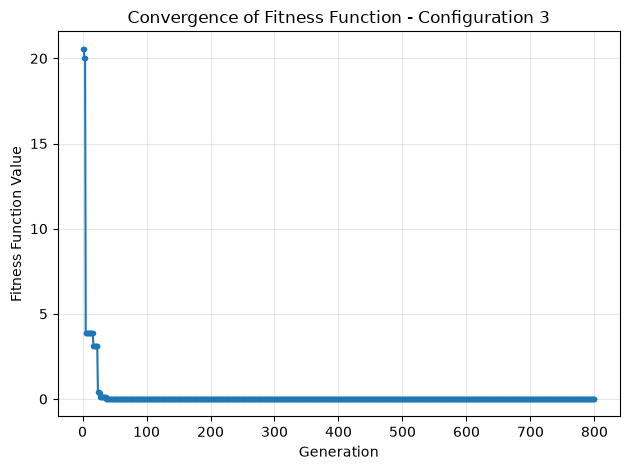

Configuration 4:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  -342.5788       60.1379        
PB                   -221.0025       47.3359        
RPU                  151.3457        -58.8442       
MES                  -44.7609        -43.4173       
MT20                 218.8164        217.5485       


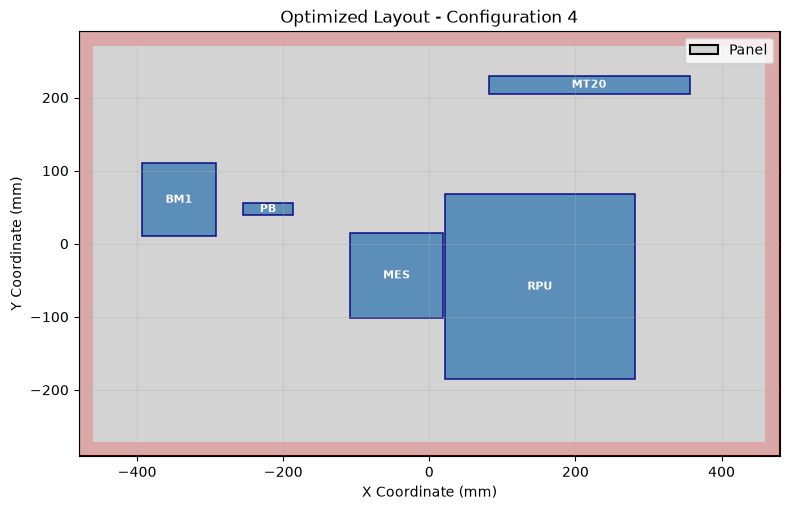

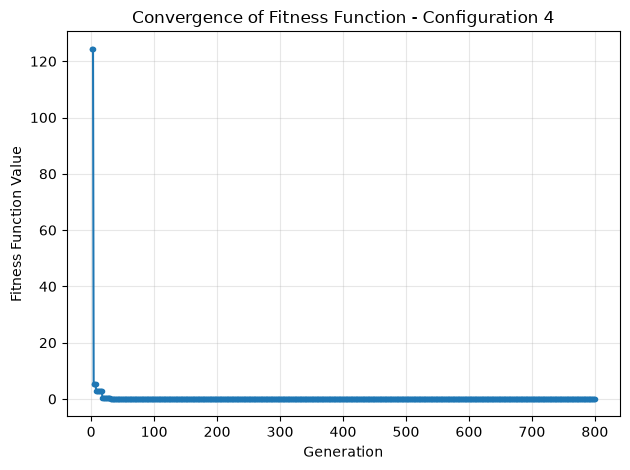

Configuration 5:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  187.4982        150.1973       
PB                   391.7006        -220.1749      
RPU                  -98.4266        -92.7280       
MES                  109.7594        -175.6034      
MT20                 -97.1439        242.1402       


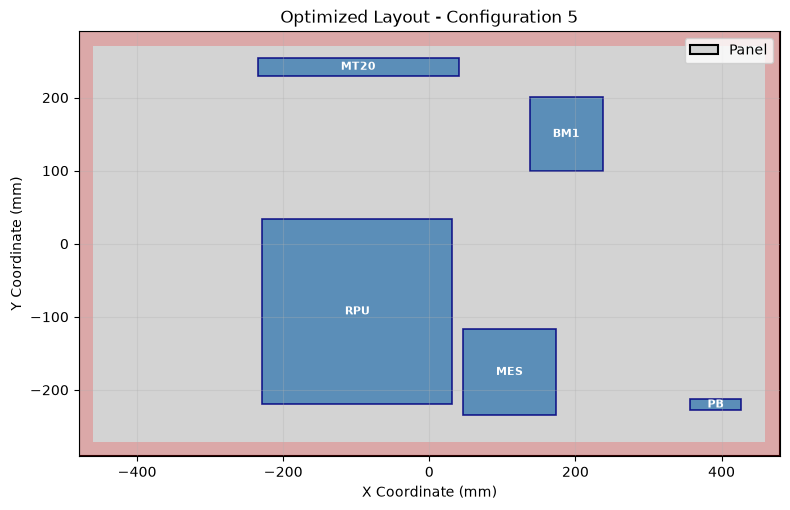

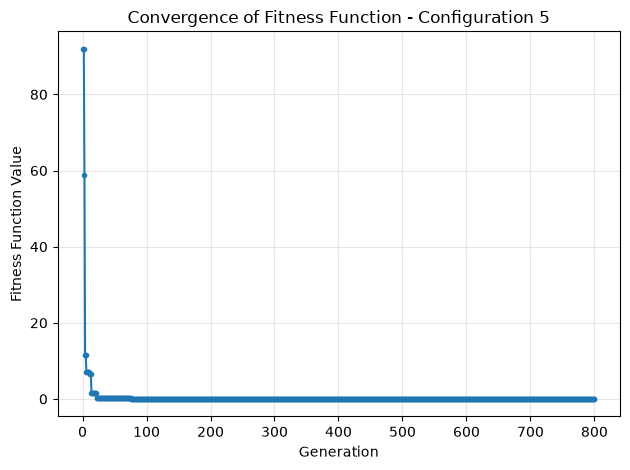

Process complete.


In [2]:
# 2. Border Constraint Optimization
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
import json

def evaluate(individual, element_data, num_elements):
    """Computes the squared center-of-gravity offset and applies a continuous penalty for overlaps."""
    masses = element_data[:, 0]
    total_mass = np.sum(masses)
    cg_x = sum(x * m for x, m in zip(individual[::2], masses)) / total_mass
    cg_y = sum(y * m for y, m in zip(individual[1::2], masses)) / total_mass
    base_fitness = cg_x**2 + cg_y**2

    penalty = 0.0
    penalty_scale = 1e8
    for i in range(num_elements):
        xi, yi = individual[2 * i], individual[2 * i + 1]
        li, wi = element_data[i, 1], element_data[i, 2]
        for j in range(i + 1, num_elements):
            xj, yj = individual[2 * j], individual[2 * j + 1]
            lj, wj = element_data[j, 1], element_data[j, 2]
            
            x_penetration = max(0.0, (li + lj) / 2.0 - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 - abs(yi - yj))
            
            if x_penetration > 1e-6 and y_penetration > 1e-6:
                penalty += x_penetration * y_penetration * penalty_scale

    return base_fitness + penalty

def is_feasible(individual, element_data, num_elements):
    """Strict validation to confirm zero overlap between all elements."""
    for i in range(num_elements):
        for j in range(i + 1, num_elements):
            xi, yi = individual[2 * i], individual[2 * i + 1]
            xj, yj = individual[2 * j], individual[2 * j + 1]
            li, wi = element_data[i, 1], element_data[i, 2]
            lj, wj = element_data[j, 1], element_data[j, 2]
            x_penetration = max(0.0, (li + lj) / 2.0 - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 - abs(yi - yj))
            if x_penetration > 1e-4 and y_penetration > 1e-4:
                return False
    return True

def main():
    # Load data from JSON file
    with open(r'/Users/neerajprao/Desktop/isro/prev_work/objects.json', 'r') as f:
        data = json.load(f)

    panel_width = float(data['BOARD']['Length (mm)'])
    panel_height = float(data['BOARD']['Breadth (mm)'])
    border_spacing = float(data['BOARD']['Border (mm)'])
    num_elements = len(data['COMPONENTS'])

    element_data = []
    element_names = []
    for component in data['COMPONENTS']:
        name = component['Object name']
        length = float(component['Length (mm)'])
        width = float(component['Breadth (mm)'])
        mass = float(component['Weight (kg)'])
        element_data.append([mass, length, width])
        element_names.append(name)

    element_data = np.array(element_data, dtype=float)

    # Pre-check feasibility against single-element border constraint
    working_width = panel_width - 2 * border_spacing
    working_height = panel_height - 2 * border_spacing
    bounds = []
    possible = True

    for i in range(num_elements):
        length = element_data[i, 1]
        width = element_data[i, 2]
        if length > working_width or width > working_height:
            possible = False
            print(f"Design infeasible: Element '{element_names[i]}' ({length}x{width} mm) exceeds working area.")
            break
        x_min = -panel_width / 2 + border_spacing + length / 2
        x_max = panel_width / 2 - border_spacing - length / 2
        y_min = -panel_height / 2 + border_spacing + width / 2
        y_max = panel_height / 2 - border_spacing - width / 2
        bounds.append((x_min, x_max))
        bounds.append((y_min, y_max))

    if not possible:
        print("Design infeasible. Please adjust element dimensions, border spacing, or panel size.")
        return

    num_desired = 5
    uniqueness_tolerance = 0.5 # mm
    unique_solutions = []
    convergence_records = []
    max_attempts = 120

    print(f"Searching for {num_desired} unique non-overlapping configurations...")

    for attempt in range(1, max_attempts + 1):
        if len(unique_solutions) >= num_desired:
            break
        convergence_data = []

        def capture_convergence(x, convergence=None):
            convergence_data.append(evaluate(x, element_data, num_elements))

        seed = np.random.randint(0, 1000000)
        result = differential_evolution(
            evaluate, bounds, args=(element_data, num_elements),
            maxiter=800, popsize=100, tol=1e-6, strategy='best1bin',
            seed=seed, callback=capture_convergence
        )
        candidate = result.x

        if not is_feasible(candidate, element_data, num_elements):
            continue

        is_unique = True
        for existing in unique_solutions:
            if np.max(np.abs(candidate - existing)) < uniqueness_tolerance:
                is_unique = False
                break

        if is_unique:
            unique_solutions.append(candidate)
            convergence_records.append(list(convergence_data))
            print(f"Identified valid unique configuration {len(unique_solutions)}/{num_desired}")

    if len(unique_solutions) < num_desired:
        print(f"\nOnly {len(unique_solutions)} unique configuration(s) found out of {num_desired} requested.")
    else:
        print(f"\nSuccessfully identified {num_desired} unique configurations.\n")

    for idx, sol in enumerate(unique_solutions, 1):
        total_mass = np.sum(element_data[:, 0])
        final_cg_x = sum(x * m for x, m in zip(sol[::2], element_data[:, 0])) / total_mass
        final_cg_y = sum(y * m for y, m in zip(sol[1::2], element_data[:, 0])) / total_mass

        print(f"Configuration {idx}:")
        print("-" * 55)
        print(f"CG Offset X: {final_cg_x:.4f} mm | CG Offset Y: {final_cg_y:.4f} mm")
        print(f"{'Element':<20} {'Center X':<15} {'Center Y':<15}")
        print("-" * 55)
        for i in range(num_elements):
            print(f"{element_names[i]:<20} {sol[2*i]:<15.4f} {sol[2*i+1]:<15.4f}")

        # LAYOUT PLOT
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_xlim(-panel_width / 2, panel_width / 2)
        ax.set_ylim(-panel_height / 2, panel_height / 2)
        ax.set_xlabel("X Coordinate (mm)")
        ax.set_ylabel("Y Coordinate (mm)")
        ax.set_title(f"Optimized Layout - Configuration {idx}")
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, panel_height,
                                facecolor='lightgray', edgecolor='black', linewidth=1.5, label='Panel'))

        border_zone_style = dict(facecolor='red', alpha=0.2, edgecolor='none')
        ax.add_patch(plt.Rectangle((-panel_width/2, panel_height/2 - border_spacing), panel_width, border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((panel_width/2 - border_spacing, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_zone_style))

        for i in range(num_elements):
            cx, cy = sol[2 * i], sol[2 * i + 1]
            lw, wh = element_data[i, 1], element_data[i, 2]
            ax.add_patch(plt.Rectangle((cx - lw / 2, cy - wh / 2), lw, wh, facecolor='steelblue', edgecolor='navy', linewidth=1.2, alpha=0.85))
            ax.text(cx, cy, element_names[i], color='white', ha='center', va='center', fontsize=8, fontweight='bold')

        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        # CONVERGENCE PLOT
        plt.figure()
        gen_data = convergence_records[idx - 1]
        if len(gen_data) > 0:
            plt.plot(range(1, len(gen_data) + 1), gen_data, marker='o', linestyle='-', markersize=3)
            plt.xlabel("Generation")
            plt.ylabel("Fitness Function Value")
            plt.title(f"Convergence of Fitness Function - Configuration {idx}")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    print("Process complete.")

if __name__ == "__main__":
    main()

Searching for 5 unique configurations (clearance: 20.0 mm)...
Identified valid unique configuration 1/5
Identified valid unique configuration 2/5
Identified valid unique configuration 3/5
Identified valid unique configuration 4/5
Identified valid unique configuration 5/5
Configuration 1:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  308.0109        20.8008        
PB                   190.1707        92.1197        
RPU                  -196.1036       5.0781         
MES                  326.5764        179.8391       
MT20                 166.1385        -195.3183      


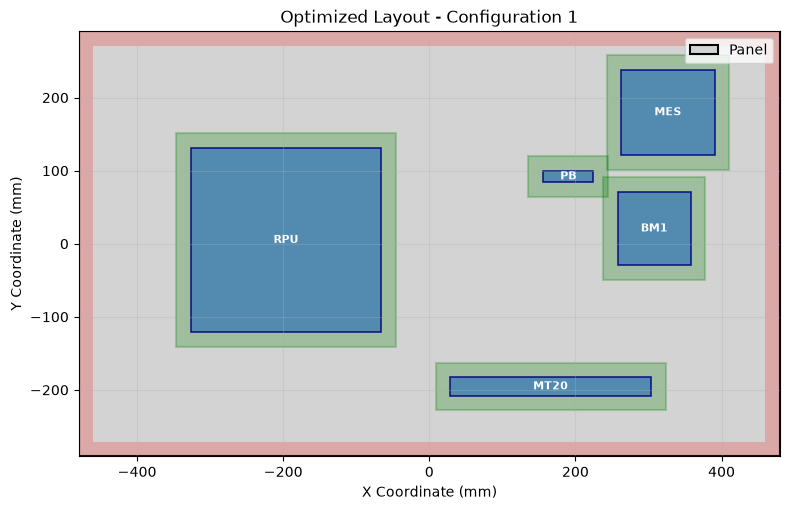

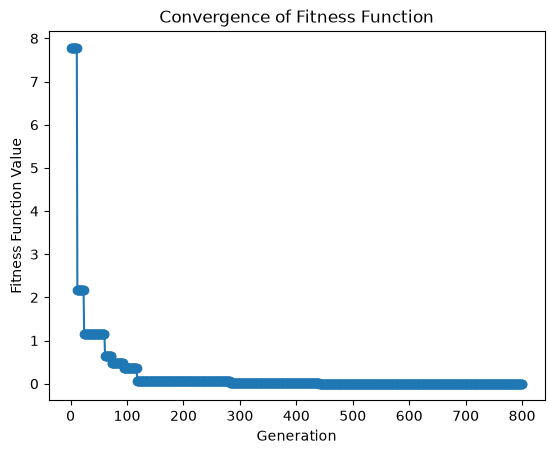

Configuration 2:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  -365.5696       171.9002       
PB                   -196.8151       241.6359       
RPU                  237.5337        -70.2667       
MES                  -184.9938       -36.7857       
MT20                 -303.6028       -166.5385      


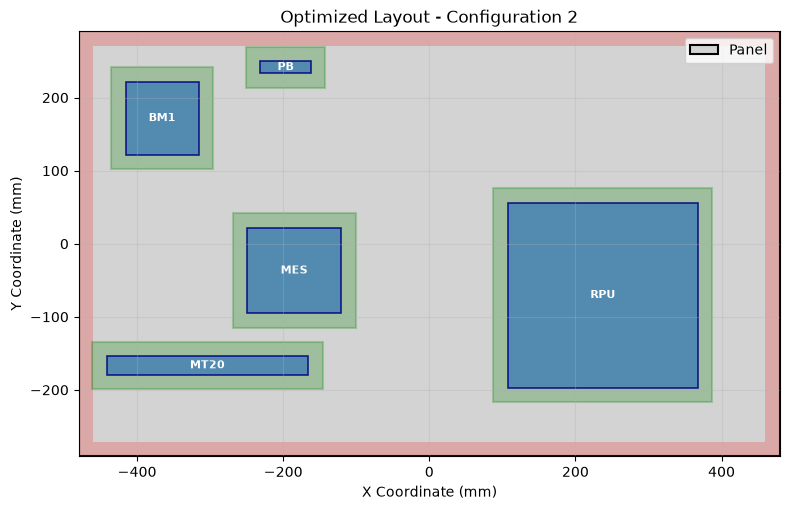

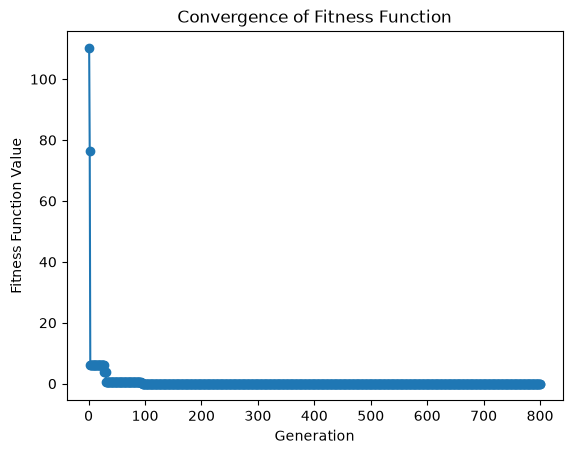

Configuration 3:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  355.8129        146.7763       
PB                   13.3560         146.0938       
RPU                  -219.4314       -109.4796      
MES                  215.9338        -5.8784        
MT20                 240.6190        235.9995       


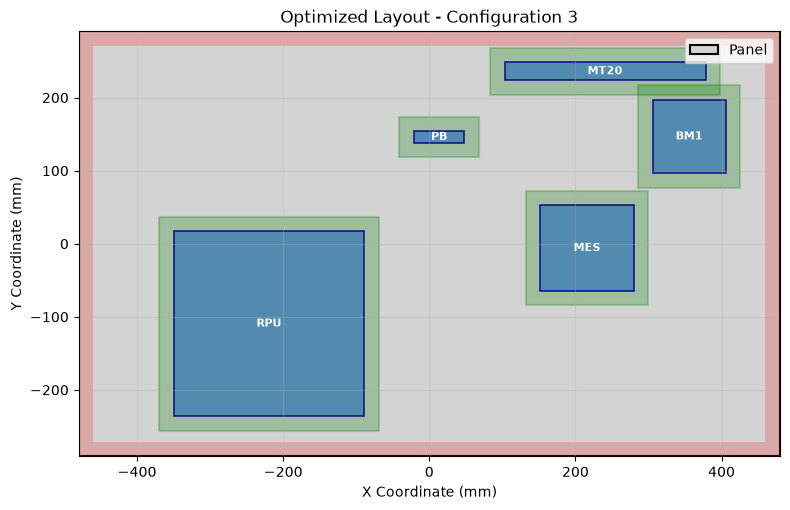

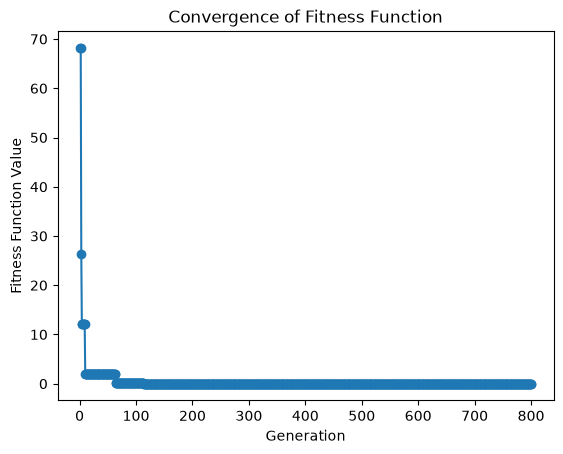

Configuration 4:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  373.0800        200.7306       
PB                   154.1343        238.9548       
RPU                  -158.8586       -143.1100      
MES                  57.8070         15.3899        
MT20                 -264.2085       256.0373       


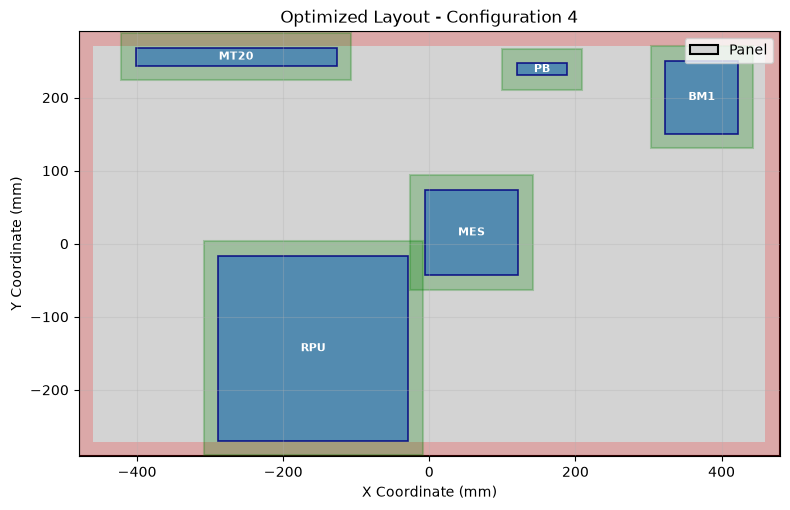

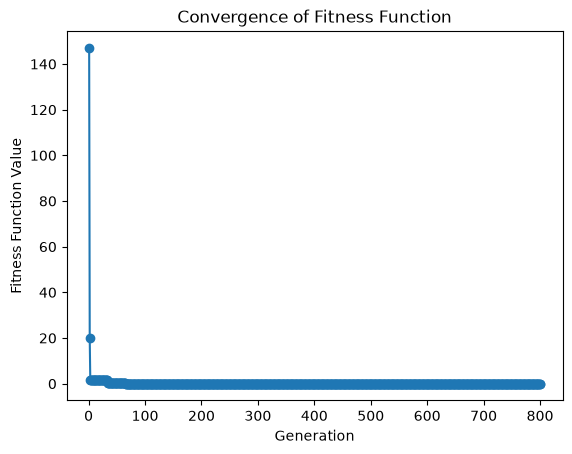

Configuration 5:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
BM1                  174.1859        -66.6601       
PB                   173.0039        -170.4178      
RPU                  -49.0840        76.1731        
MES                  -291.3970       -143.0172      
MT20                 -237.2562       -234.0251      


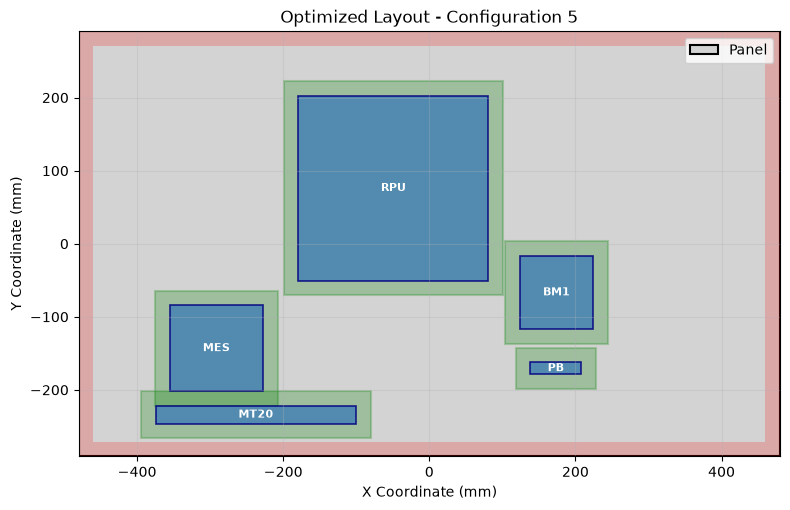

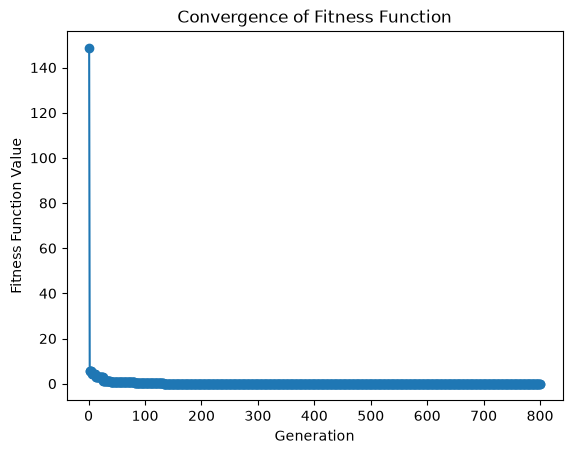

Process complete.


In [3]:
# 3. Constraint 2: Added clearance space
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
import json

def evaluate(individual, element_data, num_elements, clearance):
    """Computes the squared CG offset and applies penalty for overlaps/insufficient clearance."""
    masses = element_data[:, 0]
    total_mass = np.sum(masses)
    cg_x = sum(x * m for x, m in zip(individual[::2], masses)) / total_mass
    cg_y = sum(y * m for y, m in zip(individual[1::2], masses)) / total_mass
    base_fitness = cg_x**2 + cg_y**2

    penalty = 0.0
    penalty_scale = 1e8
    for i in range(num_elements):
        xi, yi = individual[2 * i], individual[2 * i + 1]
        li, wi = element_data[i, 1], element_data[i, 2]
        for j in range(i + 1, num_elements):
            xj, yj = individual[2 * j], individual[2 * j + 1]
            lj, wj = element_data[j, 1], element_data[j, 2]
            
            x_penetration = max(0.0, (li + lj) / 2.0 + clearance - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 + clearance - abs(yi - yj))
            
            if x_penetration > 1e-6 and y_penetration > 1e-6:
                penalty += x_penetration * y_penetration * penalty_scale

    return base_fitness + penalty

def is_feasible(individual, element_data, num_elements, clearance):
    """Strict validation to confirm zero overlap and minimum clearance between all elements."""
    for i in range(num_elements):
        for j in range(i + 1, num_elements):
            xi, yi = individual[2 * i], individual[2 * i + 1]
            xj, yj = individual[2 * j], individual[2 * j + 1]
            li, wi = element_data[i, 1], element_data[i, 2]
            lj, wj = element_data[j, 1], element_data[j, 2]
            
            x_penetration = max(0.0, (li + lj) / 2.0 + clearance - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 + clearance - abs(yi - yj))
            
            if x_penetration > 1e-4 and y_penetration > 1e-4:
                return False
    return True

def main():
    # Load data from JSON file
    with open(r'/Users/neerajprao/Desktop/isro/prev_work/objects.json', 'r') as f:
        data = json.load(f)

    panel_width = float(data['BOARD']['Length (mm)'])
    panel_height = float(data['BOARD']['Breadth (mm)'])
    border_spacing = float(data['BOARD']['Border (mm)'])
    num_elements = len(data['COMPONENTS'])
    clearance = float(data['BOARD']['Clearance (mm)'])

    element_data = []
    element_names = []
    for component in data['COMPONENTS']:
        name = component['Object name']
        length = float(component['Length (mm)'])
        width = float(component['Breadth (mm)'])
        mass = float(component['Weight (kg)'])
        element_data.append([mass, length, width])
        element_names.append(name)

    element_data = np.array(element_data, dtype=float)

    working_width = panel_width - 2 * border_spacing
    working_height = panel_height - 2 * border_spacing
    bounds = []
    possible = True

    for i in range(num_elements):
        length = element_data[i, 1]
        width = element_data[i, 2]
        if length > working_width or width > working_height:
            possible = False
            print(f"Design infeasible: Element '{element_names[i]}' exceeds working area.")
            break
        x_min = -panel_width / 2 + border_spacing + length / 2
        x_max = panel_width / 2 - border_spacing - length / 2
        y_min = -panel_height / 2 + border_spacing + width / 2
        y_max = panel_height / 2 - border_spacing - width / 2
        bounds.append((x_min, x_max))
        bounds.append((y_min, y_max))

    if not possible:
        print("Design infeasible. Please adjust element dimensions, border spacing, or panel size.")
        return

    num_desired = 5
    uniqueness_tolerance = 0.5
    unique_solutions = []
    solution_convergences = []
    max_attempts = 120

    print(f"Searching for {num_desired} unique configurations (clearance: {clearance} mm)...")

    for attempt in range(1, max_attempts + 1):
        if len(unique_solutions) >= num_desired:
            break
        seed = np.random.randint(0, 1000000)
        conv_data = []

        def track_convergence(x, convergence=None):
            conv_data.append(evaluate(x, element_data, num_elements, clearance))

        result = differential_evolution(
            evaluate, bounds, args=(element_data, num_elements, clearance),
            maxiter=800, popsize=100, tol=1e-6, strategy='best1bin',
            seed=seed, callback=track_convergence
        )
        candidate = result.x

        if not is_feasible(candidate, element_data, num_elements, clearance):
            continue

        is_unique = True
        for existing in unique_solutions:
            if np.max(np.abs(candidate - existing)) < uniqueness_tolerance:
                is_unique = False
                break

        if is_unique:
            unique_solutions.append(candidate)
            solution_convergences.append(list(conv_data))
            print(f"Identified valid unique configuration {len(unique_solutions)}/{num_desired}")

    for idx, sol in enumerate(unique_solutions, 1):
        total_mass = np.sum(element_data[:, 0])
        final_cg_x = sum(x * m for x, m in zip(sol[::2], element_data[:, 0])) / total_mass
        final_cg_y = sum(y * m for y, m in zip(sol[1::2], element_data[:, 0])) / total_mass

        print(f"Configuration {idx}:")
        print("-" * 55)
        print(f"CG Offset X: {final_cg_x:.4f} mm | CG Offset Y: {final_cg_y:.4f} mm")
        print(f"{'Element':<20} {'Center X':<15} {'Center Y':<15}")
        print("-" * 55)
        for i in range(num_elements):
            print(f"{element_names[i]:<20} {sol[2*i]:<15.4f} {sol[2*i+1]:<15.4f}")

        # Plotting Layout
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_xlim(-panel_width / 2, panel_width / 2)
        ax.set_ylim(-panel_height / 2, panel_height / 2)
        ax.set_xlabel("X Coordinate (mm)")
        ax.set_ylabel("Y Coordinate (mm)")
        ax.set_title(f"Optimized Layout - Configuration {idx}")
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, panel_height,
                                facecolor='lightgray', edgecolor='black', linewidth=1.5, label='Panel'))

        border_zone_style = dict(facecolor='red', alpha=0.2, edgecolor='none')
        ax.add_patch(plt.Rectangle((-panel_width/2, panel_height/2 - border_spacing), panel_width, border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((panel_width/2 - border_spacing, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_zone_style))

        # Clearance zones (Green)
        for i in range(num_elements):
            cx, cy = sol[2 * i], sol[2 * i + 1]
            lw, wh = element_data[i, 1], element_data[i, 2]
            clearance_rect = plt.Rectangle(
                (cx - lw / 2 - clearance, cy - wh / 2 - clearance),
                lw + 2 * clearance, wh + 2 * clearance,
                facecolor='green', alpha=0.25, edgecolor='green', linewidth=1.5
            )
            ax.add_patch(clearance_rect)

        # Element placements (Blue)
        for i in range(num_elements):
            cx, cy = sol[2 * i], sol[2 * i + 1]
            lw, wh = element_data[i, 1], element_data[i, 2]
            ax.add_patch(plt.Rectangle((cx - lw / 2, cy - wh / 2), lw, wh, facecolor='steelblue', edgecolor='navy', linewidth=1.2, alpha=0.85))
            ax.text(cx, cy, element_names[i], color='white', ha='center', va='center', fontsize=8, fontweight='bold')

        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        convergence_data = solution_convergences[idx - 1]
        if convergence_data:
            plt.figure()
            plt.plot(range(1, len(convergence_data) + 1), convergence_data, marker='o', linestyle='-')
            plt.xlabel("Generation")
            plt.ylabel("Fitness Function Value")
            plt.title("Convergence of Fitness Function")
            plt.show()

    print("Process complete.")

if __name__ == "__main__":
    main()


Running optimization to generate distinct layouts...

Found layout 1/5.

Found layout 2/5.

Found layout 3/5.

Found layout 4/5.

Found layout 5/5.

DISPLAYING RESULTS: TABLE ABOVE EACH LARGE SQUARE DIAGRAM

--- Layout 1 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
BM1                375.9176        -79.7846        1.50       6.0
PB                 -339.0764       21.3633         0.10       4.0
RPU                -142.0190       64.6838         3.00       4.0
MES                170.1685        -89.4261        0.12       6.0
MT20               -312.8776       -163.5566       0.40       4.0


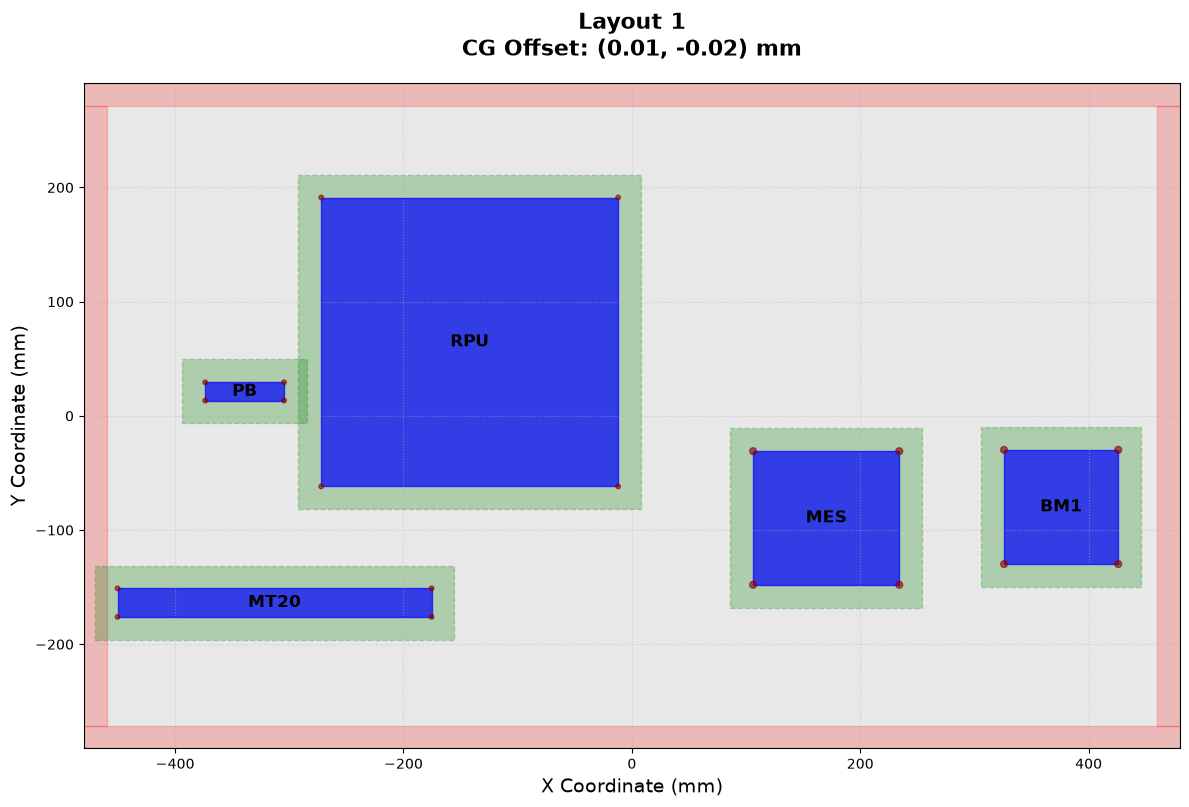

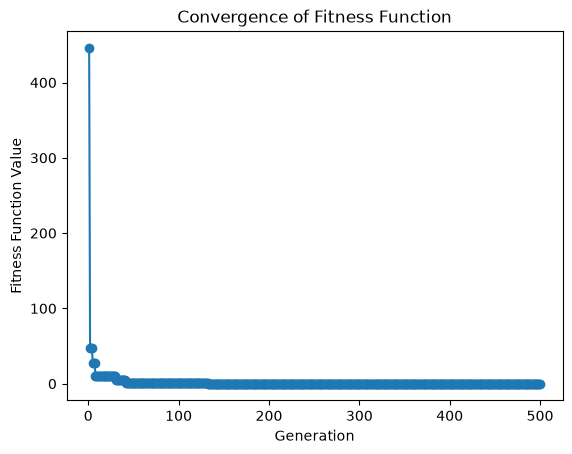


--- Layout 2 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
BM1                -325.8905       31.2973         1.50       6.0
PB                 -112.8096       -141.3728       0.10       4.0
RPU                198.6430        -27.3857        3.00       4.0
MES                -242.1210       -142.2499       0.12       6.0
MT20               -163.8963       167.7793        0.40       4.0


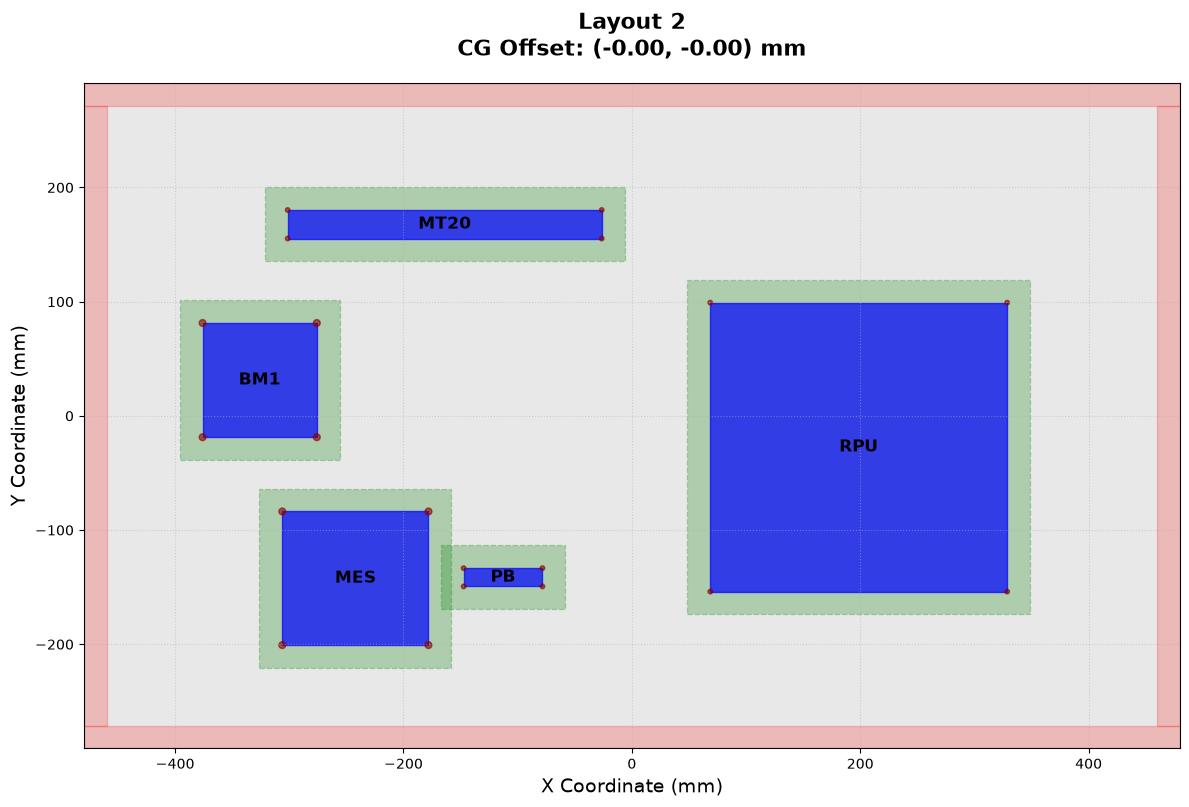

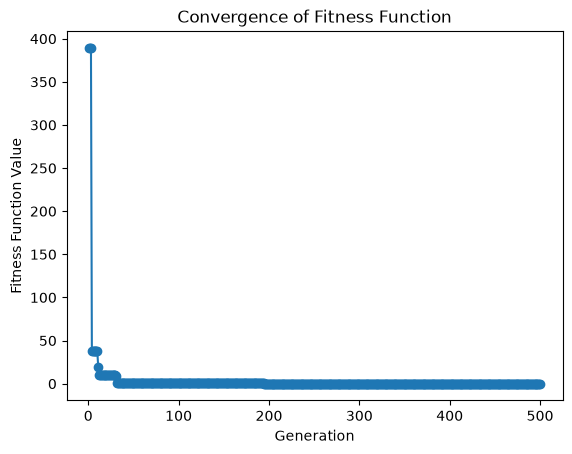


--- Layout 3 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
BM1                -392.2257       -46.4489        1.50       6.0
PB                 -418.9451       -184.4126       0.10       4.0
RPU                222.5433        6.6435          3.00       4.0
MES                -110.5163       -23.3888        0.12       6.0
MT20               -58.7441        177.5071        0.40       4.0


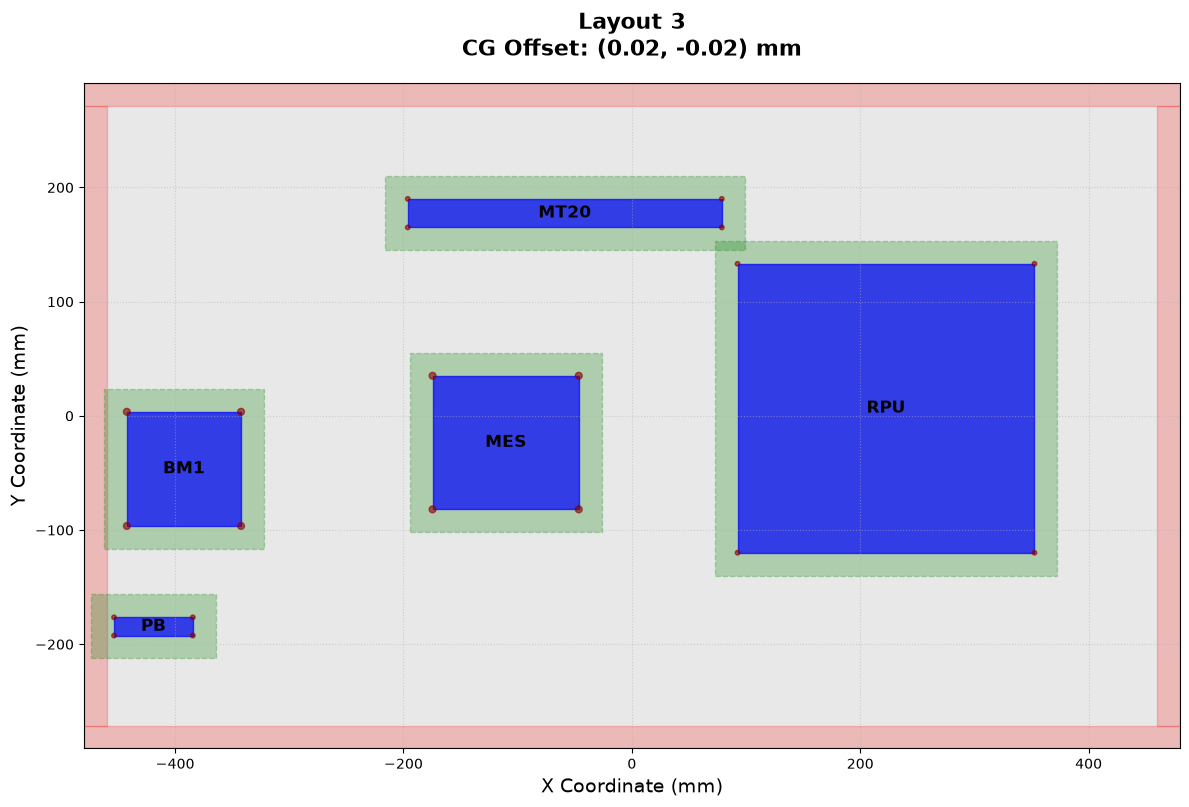

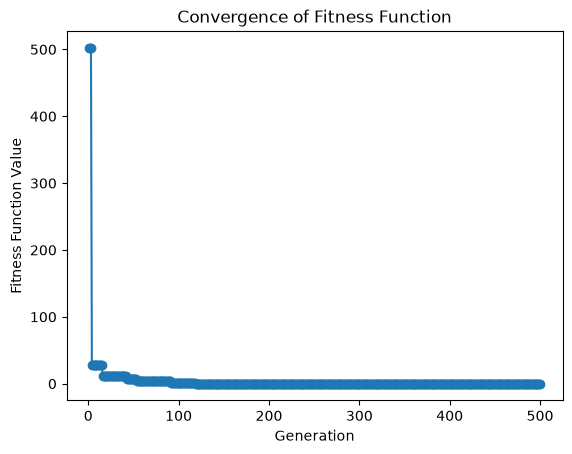


--- Layout 4 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
BM1                355.7648        -184.0948       1.50       6.0
PB                 -281.6610       -229.7962       0.10       4.0
RPU                -158.3955       135.3568        3.00       4.0
MES                -164.0348       -103.4557       0.12       6.0
MT20               -23.8380        -235.0650       0.40       4.0


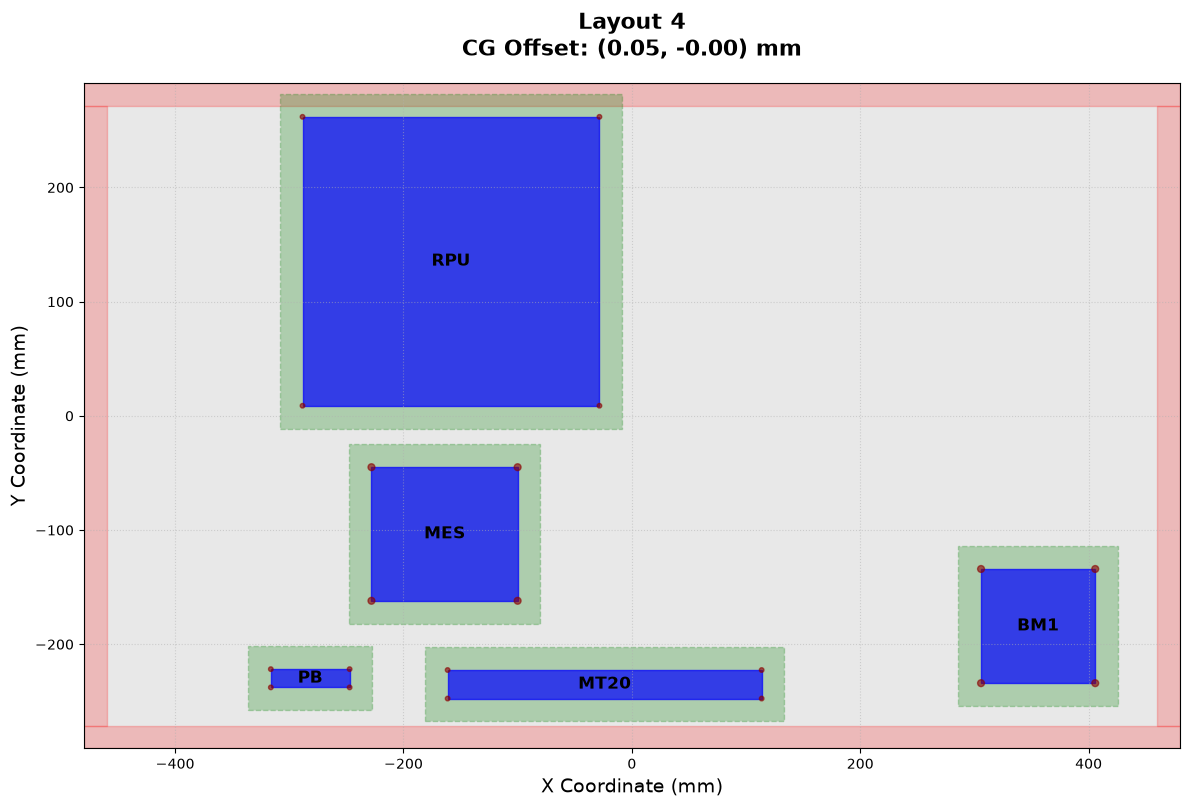

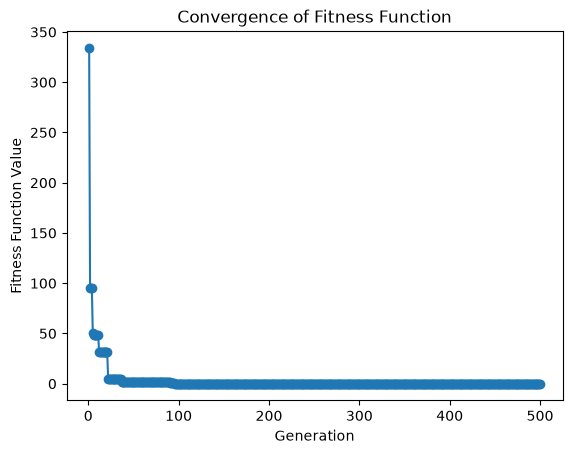


--- Layout 5 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
BM1                -234.3326       -172.3532       1.50       6.0
PB                 80.7777         -199.1871       0.10       4.0
RPU                61.9337         110.7247        3.00       4.0
MES                361.2953        16.9146         0.12       6.0
MT20               281.1649        -139.6011       0.40       4.0


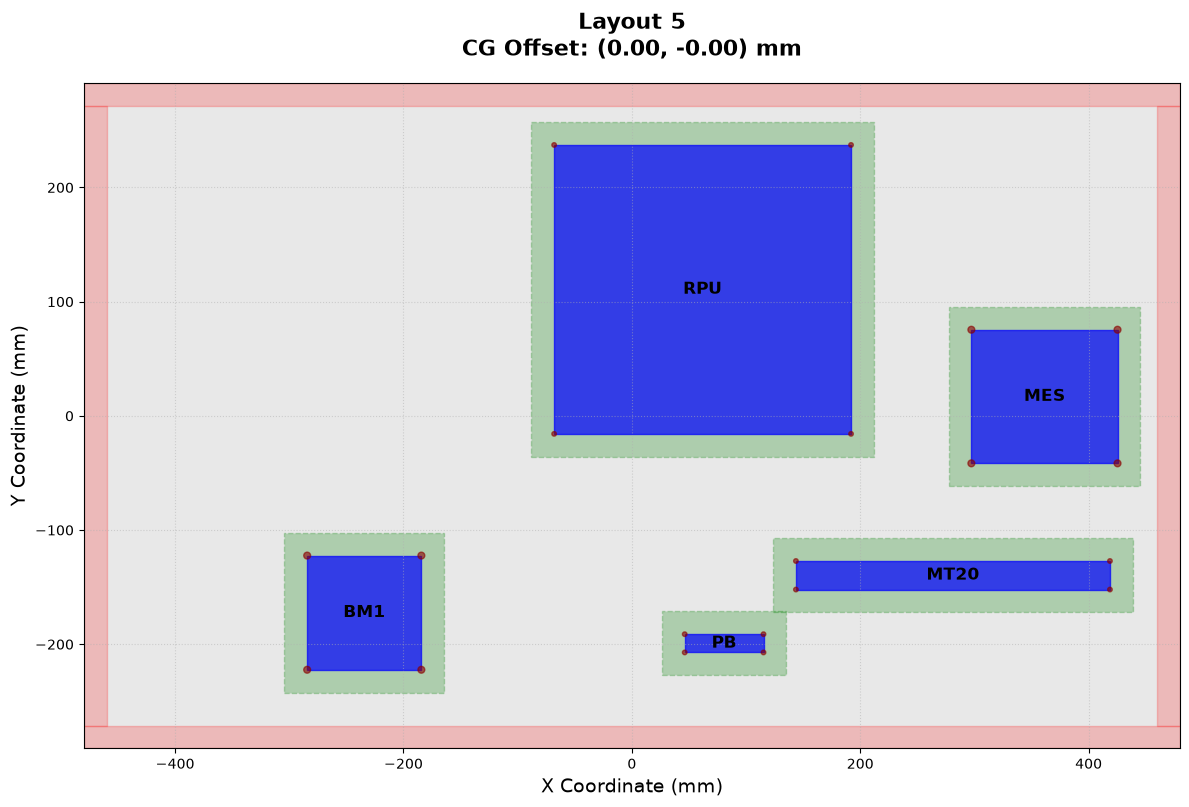

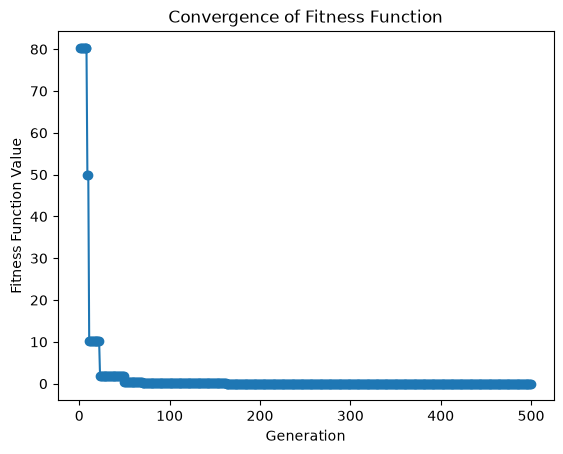

In [5]:
# 4. JSON Input Phase Optimization with Corner Inserts
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings("ignore")

# ================= FAST & ROBUST FITNESS EVALUATION =================
def evaluate(individual, masses, lengths, widths, insert_diams, req_d_matrix, clearance):
    n = len(masses)
    cx = individual[::2]
    cy = individual[1::2]
    hl = lengths / 2.0
    hw = widths / 2.0

    total_mass = np.sum(masses)
    cg_x = np.sum(cx * masses) / total_mass
    cg_y = np.sum(cy * masses) / total_mass
    base_fitness = cg_x**2 + cg_y**2

    penalty = 0.0

    # Vectorized clearance penalty
    diff_x = np.abs(cx[:, None] - cx[None, :])
    diff_y = np.abs(cy[:, None] - cy[None, :])
    req_dx = hl[:, None] + hl[None, :] + clearance
    req_dy = hw[:, None] + hw[None, :] + clearance

    overlap_x = np.maximum(0.0, req_dx - diff_x)
    overlap_y = np.maximum(0.0, req_dy - diff_y)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    penalty += np.sum(overlap_x[mask] * overlap_y[mask]) * 1e6

    # Optimized insert distance penalty
    for i in range(n):
        for j in range(i + 1, n):
            xi, yi = cx[i], cy[i]
            xj, yj = cx[j], cy[j]
            li, wi = lengths[i], widths[i]
            lj, wj = lengths[j], widths[j]

            xi_c = np.array([xi - li/2, xi + li/2, xi - li/2, xi + li/2])
            yi_c = np.array([yi - wi/2, yi - wi/2, yi + wi/2, yi + wi/2])
            xj_c = np.array([xj - lj/2, xj + lj/2, xj - lj/2, xj + lj/2])
            yj_c = np.array([yj - wj/2, yj - wj/2, yj + wj/2, yj + wj/2])

            dx = xi_c[:, None] - xj_c[None, :]
            dy = yi_c[:, None] - yj_c[None, :]
            dists = np.sqrt(dx**2 + dy**2)

            req = req_d_matrix[i, j]
            penalty += np.sum(np.maximum(0.0, req - dists)) * 1e6

    return base_fitness + penalty

# ================= JSON INPUT PHASE =================
with open(r'objects.json', 'r') as f:
    data = json.load(f)

panel_width = float(data['BOARD']['Length (mm)'])
panel_height = float(data['BOARD']['Breadth (mm)'])
border_spacing = float(data['BOARD']['Border (mm)'])
num_elements = len(data['COMPONENTS'])
clearance = float(data['BOARD']['Clearance (mm)'])

element_data = []
element_names = []

for component in data['COMPONENTS']:
    element_name = component['Object name']
    length = float(component['Length (mm)'])
    width = float(component['Breadth (mm)'])
    mass = float(component['Weight (kg)'])
    insert_diam = float(component['Insert (mm)'])
    element_data.append([mass, length, width, insert_diam])
    element_names.append(element_name)

element_data = np.array(element_data, dtype=float)

# ================= FEASIBILITY & BOUNDS CHECK =================
working_width = panel_width - 2 * border_spacing
working_height = panel_height - 2 * border_spacing
possible = True
bounds = []

for i in range(num_elements):
    length = element_data[i, 1]
    width = element_data[i, 2]
    insert_radius = element_data[i, 3] / 2.0

    if length > working_width or width > working_height:
        possible = False
        print(f"Design impossible: Element '{element_names[i]}' exceeds available area.")
        break

    x_min = -panel_width / 2 + border_spacing + length / 2 + insert_radius
    x_max = panel_width / 2 - border_spacing - length / 2 - insert_radius
    y_min = -panel_height / 2 + border_spacing + width / 2 + insert_radius
    y_max = panel_height / 2 - border_spacing - width / 2 - insert_radius
    bounds.append((x_min, x_max))
    bounds.append((y_min, y_max))

# ================= MULTI-OUTPUT OPTIMIZATION PHASE =================
if possible:
    masses = element_data[:, 0]
    lengths = element_data[:, 1]
    widths = element_data[:, 2]
    insert_diams = element_data[:, 3]
    n = len(element_data)

    req_d_matrix = np.empty((n, n))
    for i in range(n):
        for j in range(n):
            if insert_diams[i] == 4.0 and insert_diams[j] == 4.0:
                req_d_matrix[i, j] = 24.0
            elif insert_diams[i] == 6.0 and insert_diams[j] == 6.0:
                req_d_matrix[i, j] = 36.0
            else:
                req_d_matrix[i, j] = 30.0

    distinct_layouts = []
    layout_convergences = []
    max_attempts = 300
    attempt = 0

    print("\nRunning optimization to generate distinct layouts...")
    while len(distinct_layouts) < 5 and attempt < max_attempts:
        attempt += 1
        seed = int(np.random.default_rng().integers(0, 2**31 - 1))
        conv_data = []

        def track_convergence(x, convergence=None):
            conv_data.append(evaluate(x, masses, lengths, widths, insert_diams, req_d_matrix, clearance))

        try:
            result = differential_evolution(
                evaluate, bounds,
                args=(masses, lengths, widths, insert_diams, req_d_matrix, clearance),
                maxiter=500, popsize=50, tol=1e-6,
                strategy='best1bin', seed=seed, polish=False, updating='deferred',
                callback=track_convergence
            )
            current_layout = result.x

            if np.any(np.isinf(current_layout)) or np.any(np.isnan(current_layout)):
                continue

            is_distinct = True
            for existing in distinct_layouts:
                if np.max(np.abs(current_layout - existing)) < 1.0:
                    is_distinct = False
                    break

            if is_distinct:
                distinct_layouts.append(current_layout)
                layout_convergences.append(list(conv_data))
                print(f"\nFound layout {len(distinct_layouts)}/5.")

        except Exception as e:
            print(f"Attempt {attempt} failed: {e}. Continuing...")
            continue

    total_mass = sum(masses)

    # ================= VISUALIZATION & RESULTS PHASE =================
    if len(distinct_layouts) == 0:
        print("\nNo feasible layouts could be generated. Adjust constraints and run again.")
    else:
        print("\n" + "=" * 80)
        print("DISPLAYING RESULTS: TABLE ABOVE EACH LARGE SQUARE DIAGRAM")
        print("=" * 80)

        for idx, layout in enumerate(distinct_layouts):
            layout_idx = idx + 1
            final_cg_x = sum(x * m for x, m in zip(layout[::2], masses)) / total_mass
            final_cg_y = sum(y * m for y, m in zip(layout[1::2], masses)) / total_mass

            print(f"\n--- Layout {layout_idx} ---")
            print(f"{'Element Name':<18} {'Center X (mm)':<15} {'Center Y (mm)':<15} {'Mass (kg)':<10} {'Insert Dia (mm)'}")
            print("-" * 73)
            for i in range(num_elements):
                ex = layout[i * 2]
                ey = layout[i * 2 + 1]
                mass = element_data[i, 0]
                diam = element_data[i, 3]
                print(f"{element_names[i]:<18} {ex:<15.4f} {ey:<15.4f} {mass:<10.2f} {diam}")
            print("=" * 73)

            fig, ax = plt.subplots(figsize=(12, 12))
            ax.set_title(f"Layout {layout_idx}\nCG Offset: ({final_cg_x:.2f}, {final_cg_y:.2f}) mm",
                         fontsize=16, fontweight='bold', pad=20)

            ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, panel_height, color='lightgray', alpha=0.5))

            border_style = dict(color='red', alpha=0.2)
            ax.add_patch(plt.Rectangle((-panel_width/2, panel_height/2 - border_spacing), panel_width, border_spacing, **border_style))
            ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, border_spacing, **border_style))
            ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_style))
            ax.add_patch(plt.Rectangle((panel_width/2 - border_spacing, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_style))

            for i in range(num_elements):
                ex = layout[i * 2]
                ey = layout[i * 2 + 1]
                el_length = lengths[i]
                el_width = widths[i]
                insert_diam = insert_diams[i]
                insert_rad = insert_diam / 2.0

                ax.add_patch(plt.Rectangle((ex - el_length/2 - clearance, ey - el_width/2 - clearance),
                                           el_length + 2*clearance, el_width + 2*clearance,
                                           color='green', alpha=0.25, edgecolor='green', linestyle='--'))

                ax.add_patch(plt.Rectangle((ex - el_length/2, ey - el_width/2), el_length, el_width, color='blue', alpha=0.7))

                corners = [
                    (ex - el_length/2, ey - el_width/2),
                    (ex + el_length/2, ey - el_width/2),
                    (ex - el_length/2, ey + el_width/2),
                    (ex + el_length/2, ey + el_width/2)
                ]
                for cx_c, cy_c in corners:
                    ax.add_patch(plt.Circle((cx_c, cy_c), insert_rad, color='darkred', alpha=0.6))

                ax.text(ex, ey, element_names[i], color='black', ha='center', va='center', fontsize=12, fontweight='bold')

            ax.set_xlim(-panel_width/2, panel_width/2)
            ax.set_ylim(-panel_height/2, panel_height/2)
            ax.set_xlabel("X Coordinate (mm)", fontsize=14)
            ax.set_ylabel("Y Coordinate (mm)", fontsize=14)
            ax.set_aspect('equal')
            ax.grid(True, linestyle=':', alpha=0.5)

            plt.tight_layout()
            plt.show()
            plt.close(fig)

            convergence_data = layout_convergences[idx]
            if convergence_data:
                plt.figure()
                plt.plot(range(1, len(convergence_data) + 1), convergence_data, marker='o', linestyle='-')
                plt.xlabel("Generation")
                plt.ylabel("Fitness Function Value")
                plt.title("Convergence of Fitness Function")
                plt.show()

        if len(distinct_layouts) < 5:
            print(f"\nNote: Only {len(distinct_layouts)} distinct layout(s) could be generated within {attempt} attempts.")
else:
    print("Design impossible: The specified constraints cannot be satisfied.")